In [1]:
!nvidia-smi

Sun Mar 15 17:34:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             27W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/qcf-568/DocTamper.git
%cd DocTamper

Cloning into 'DocTamper'...
remote: Enumerating objects: 363, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 363 (delta 101), reused 70 (delta 69), pack-reused 245 (from 1)
Receiving objects: 100% (363/363), 1.52 MiB | 23.94 MiB/s, done.
Resolving deltas: 100% (191/191), done.
/kaggle/working/DocTamper


In [3]:
!pip install lmdb jpegio albumentations opencv-python tqdm
!pip install segmentation-models-pytorch
!pip install pytesseract easyocr
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 MB 6.0 MB/s eta 0:00:0000:0100:01m
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.2/301.2 kB 16.9 MB/s eta 0:00:00
  Created wheel for jpegio: filename=jpegio-0.2.8-cp312-cp312-linux_x86_64.whl size=1277314 sha256=5e025e8bf69efd2d8bb19f3c95813253d931cc734a72cbfde77ee2ef4c052697
  Stored in directory: /root/.cache/pip/wheels/4e/5f/d9/3898c36bd7e9166a13a514d61f7ddd7310c192bfb443e758f8
Successfully built jpegio
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.0 MB/s eta 0:00:00


In [4]:
import os

dataloader_path = '/kaggle/working/DocTamper/dataloader.py'

with open(dataloader_path, 'r') as f:
    lines = f.readlines()

new_lines = []
os_imported = False
for i, line in enumerate(lines):
    if line.strip() == 'import os':
        os_imported = True
    # Correctly match the full problematic line
    if "with open('pks/'+roots+'_%d.pk'%minq,'rb') as f:" in line:
        new_lines.append(line.replace(
            "with open('pks/'+roots+'_%d.pk'%minq,'rb')",
            "with open('pks/'+os.path.basename(roots)+'_%d.pk'%minq,'rb')"
        ))
    else:
        new_lines.append(line)

# Ensure 'import os' is at the top
if not os_imported:
    new_lines.insert(0, 'import os\n')

with open(dataloader_path, 'w') as f:
    f.writelines(new_lines)

print('dataloader.py has been re-modified. Please re-run all cells from the beginning after this operation.')

dataloader.py has been re-modified. Please re-run all cells from the beginning after this operation.


In [5]:
from dataloader import DocTamperDataset
from torch.utils.data import DataLoader

dataset = DocTamperDataset(
    roots="/kaggle/input/datasets/kunalbiradar17/bits-goa-model-data/DocTamperV1-SCD",
    minq=75,
    max_nums=2000
)

loader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch in loader:
    labels = batch['label']

    print("Label tensor shape:", labels.shape)
    print("Unique values:", labels.unique())

    break

Label tensor shape: torch.Size([4, 1, 512, 512])
Unique values: tensor([0, 1])


In [6]:
import torch

total_zeros = 0
total_ones = 0

for batch in loader:

    masks = batch['label']

    total_zeros += torch.sum(masks == 0).item()
    total_ones += torch.sum(masks == 1).item()

print("Authentic pixels (0):", total_zeros)
print("Tampered pixels (1):", total_ones)

Authentic pixels (0): 519638452
Tampered pixels (1): 4649548


In [7]:
!nvidia-smi

Sun Mar 15 17:37:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             27W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..1.3328106].


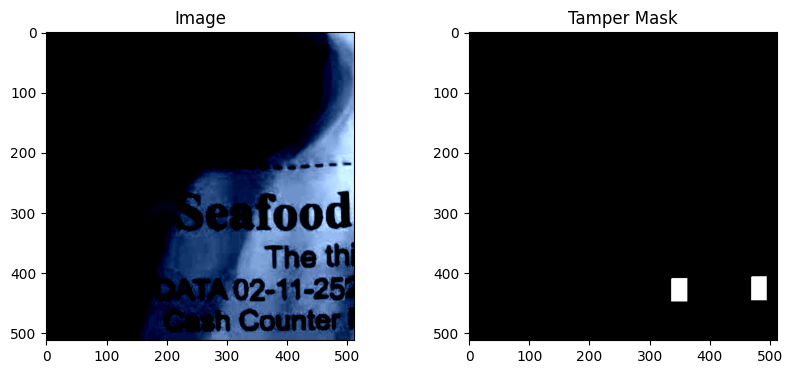

In [8]:
import matplotlib.pyplot as plt

sample = dataset[0]

image = sample['image'].permute(1,2,0)
mask = sample['label'][0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Tamper Mask")
plt.imshow(mask, cmap="gray")

plt.show()

In [9]:
len(dataset)

2000

In [10]:
for batch in loader:
    print(batch['image'].shape)
    print(batch['label'].shape)
    print(batch['dct'].shape)
    break


torch.Size([4, 3, 512, 512])
torch.Size([4, 1, 512, 512])
torch.Size([4, 512, 512])


In [11]:
import cv2
import numpy as np # Import numpy

def preprocess(img):

    img = cv2.resize(img,(512,512))

    # Ensure image is in BGR format for conversion to grayscale
    if len(img.shape) == 2 or img.shape[2] == 1: # If grayscale or 1-channel
        gray = img # Already grayscale
    elif img.shape[2] == 3:
        gray = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    else:
        # Handle other channel numbers if necessary, or raise an error
        raise ValueError("Unsupported image channel format")

    # Removed Gaussian blur as it might hinder text extraction
    # blur = cv2.GaussianBlur(gray,(5,5),0)
    processed_img = gray # Use the grayscale image directly

    # Convert to uint8 for pytesseract, if it's not already
    if processed_img.dtype != np.uint8:
        # Scale to 0-255 if it's a float image and convert to uint8
        if np.issubdtype(processed_img.dtype, np.floating):
            processed_img = (processed_img * 255).astype(np.uint8)
        else:
            # If it's another integer type, convert directly to uint8
            processed_img = processed_img.astype(np.uint8)

    return processed_img

In [12]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [13]:
import segmentation_models_pytorch as smp


model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [14]:
def compute_accuracy(preds, masks):

    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    correct = (preds == masks).float().sum()

    total = torch.numel(preds)

    return correct / total

In [15]:
def compute_iou(preds, masks):

    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * masks).sum()
    union = preds.sum() + masks.sum() - intersection

    if union == 0:
        return torch.tensor(1.0)

    return intersection / union

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(15):

    epoch_loss = 0
    epoch_acc = 0
    epoch_iou = 0
    batches = 0

    for batch in loader:

        images = batch['image'].to(device)
        masks = batch['label'].float().to(device)

        preds = model(images)

        loss = torch.nn.functional.binary_cross_entropy_with_logits(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = compute_accuracy(preds, masks)
        iou = compute_iou(preds, masks)

        epoch_loss += loss.item()
        epoch_acc += acc.item()
        epoch_iou += iou.item()
        batches += 1

    print(
        f"Epoch {epoch} | Loss: {epoch_loss/batches:.4f} | "
        f"Accuracy: {epoch_acc/batches:.4f} | IoU: {epoch_iou/batches:.4f}"
    )

Epoch 0 | Loss: 0.1228 | Accuracy: 0.9849 | IoU: 0.0857
Epoch 1 | Loss: 0.0426 | Accuracy: 0.9935 | IoU: 0.2994
Epoch 2 | Loss: 0.0311 | Accuracy: 0.9940 | IoU: 0.3609
Epoch 3 | Loss: 0.0264 | Accuracy: 0.9942 | IoU: 0.3809
Epoch 4 | Loss: 0.0231 | Accuracy: 0.9944 | IoU: 0.3955
Epoch 5 | Loss: 0.0214 | Accuracy: 0.9945 | IoU: 0.4005
Epoch 6 | Loss: 0.0197 | Accuracy: 0.9946 | IoU: 0.4197
Epoch 7 | Loss: 0.0172 | Accuracy: 0.9949 | IoU: 0.4562
Epoch 8 | Loss: 0.0155 | Accuracy: 0.9952 | IoU: 0.4902
Epoch 9 | Loss: 0.0132 | Accuracy: 0.9957 | IoU: 0.5474
Epoch 10 | Loss: 0.0119 | Accuracy: 0.9960 | IoU: 0.5807
Epoch 11 | Loss: 0.0094 | Accuracy: 0.9968 | IoU: 0.6465
Epoch 12 | Loss: 0.0086 | Accuracy: 0.9970 | IoU: 0.6773
Epoch 13 | Loss: 0.0071 | Accuracy: 0.9975 | IoU: 0.7203
Epoch 14 | Loss: 0.0058 | Accuracy: 0.9979 | IoU: 0.7644


Text(0.5, 1.0, 'Tampered Region')

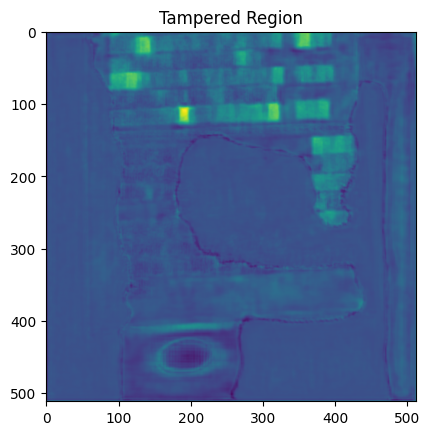

In [112]:
import matplotlib.pyplot as plt

sample = dataset[1]

img = sample['image'].unsqueeze(0).to(device)

pred = model(img)

mask = pred.detach().cpu().numpy()[0][0]

plt.imshow(mask)
plt.title("Tampered Region")

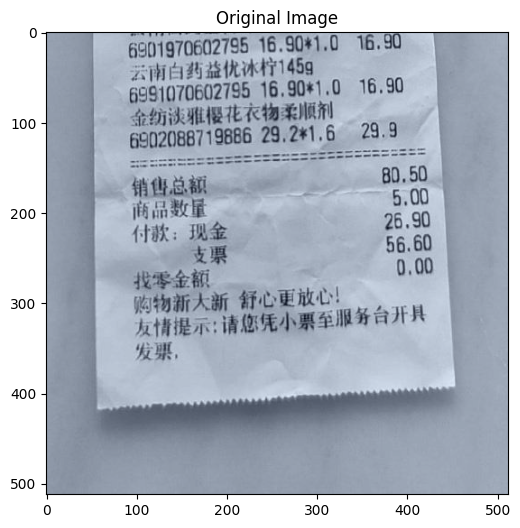

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# Get the original image tensor from the sample
original_img_tensor = sample['image']

# Convert to numpy array and transpose dimensions from (C, H, W) to (H, W, C)
original_img_np = original_img_tensor.permute(1, 2, 0).cpu().numpy()

# Normalize the image data to the [0, 1] range for proper display
min_val = original_img_np.min()
max_val = original_img_np.max()
if max_val > min_val:
    original_img_np = (original_img_np - min_val) / (max_val - min_val)
else:
    original_img_np = np.zeros_like(original_img_np) # Handle case where all pixels are the same

plt.figure(figsize=(6, 6))
plt.imshow(original_img_np)
plt.title("Original Image")
# plt.axis('off') # Hide axes for cleaner image display
plt.show()

In [114]:
!apt-get install tesseract-ocr


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 134 not upgraded.


In [115]:
!apt-get install tesseract-ocr-chi-sim

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-chi-sim is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 134 not upgraded.


In [116]:
import pytesseract

def extract_text(image):

    # Specify language for Chinese (simplified). Ensure 'tesseract-ocr-chi-sim' is installed.
    text = pytesseract.image_to_string(image, lang='chi_sim')

    return text

preprocessed_image = preprocess(original_img_np)
text = extract_text(preprocessed_image)
print(text)


6901970602795 16.90#1,0 16,90

云南白药益优冰柠1459
6991070602795 16,90+1,0 16,90 |
移纺法牙根花衣物柔顺剂          ]
6902088719886     1

                        

付款; 现金
支票

0.00 |

投零金大

购物新夫新 和记更放心 ，，
友情提示; 请您任小票至最 务台开具
发票，

 



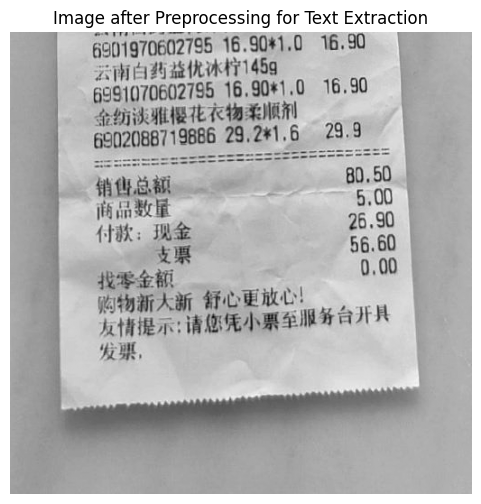

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(preprocessed_image, cmap='gray')
plt.title("Image after Preprocessing for Text Extraction")
plt.axis('off')
plt.show()

In [118]:
import easyocr

reader = easyocr.Reader(['en'])

def ocr_confidence(image):

    results = reader.readtext(image)

    confidences = [r[2] for r in results]

    if len(confidences) == 0:
        return 0

    return sum(confidences) / len(confidences)


In [119]:
import pytesseract
import re

def detect_text_anomaly(image):

    text = pytesseract.image_to_string(image)

    score = 0

    # 1️⃣ empty text
    if len(text.strip()) == 0:
        score += 0.4

    # 2️⃣ unusual characters
    special_chars = re.findall(r'[^\w\s]', text)
    if len(special_chars) > 5:
        score += 0.3

    # 3️⃣ suspicious numeric patterns
    numbers = re.findall(r'\d+', text)
    for n in numbers:
        if len(n) > 8:   # extremely long number
            score += 0.3

    return min(score,1.0)


In [120]:
import re

def detect_text_anomaly(text):
    anomaly_score = 0.0

    # Remove control characters and whitespace for checking emptiness
    cleaned_text = re.sub(r'\s+', '', text).strip()
    if not cleaned_text:
        return 1  # Anomaly if text is empty or only whitespace

    numbers = re.findall(r'\d+', text)

    # Moderate anomaly if any numbers are present
    if len(numbers) > 0:
        anomaly_score = max(anomaly_score, 0.5)

    # Higher anomaly for unusually long numbers (e.g., potential manipulation of IDs)
    for n_str in numbers:
        if len(n_str) > 8:
            anomaly_score = max(anomaly_score, 0.7) # Using 0.7 as a significant anomaly score for long numbers

    return anomaly_score # Return the highest anomaly found

In [121]:
def confidence_anomaly(conf):

    if conf > 0.85:
        return 0

    if conf > 0.7:
        return 0.2

    if conf > 0.5:
        return 0.5

    return 0.8


In [122]:
def compute_text_score(image):

    text_score = detect_text_anomaly(image)

    conf = ocr_confidence(image)

    conf_score = confidence_anomaly(conf)

    return (text_score + conf_score) / 2


In [123]:
from ultralytics import YOLO
import torch # Import torch for tensor operations

model_yolo = YOLO("yolov8n.pt")

results = model_yolo(original_img_np)

# Check if there are any detections before calculating mean confidence
if len(results[0].boxes.conf) > 0:
    signature_score = results[0].boxes.conf.mean()
else:
    # Assign a default score if no signatures are detected
    # For example, 0 means no signature found, or 0.5 for a neutral stance
    signature_score = torch.tensor(0.0, device='cuda:0') # Default to 0 if no detections

print(signature_score)


0: 640x640 (no detections), 6.9ms
Speed: 6.7ms preprocess, 6.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
tensor(0., device='cuda:0')


In [124]:
import numpy as np
import torch # Import torch for sigmoid function

def visual_score(mask):
    # Apply sigmoid to convert logits to probabilities (0-1 range)
    probabilities = torch.sigmoid(torch.tensor(mask))
    return probabilities.max().item() # Convert to Python float

In [125]:
import numpy as np

def layout_anomaly(image):
    # The 'reader' object from easyocr is already initialized in cell 'munHZSuaDY0p'
    # We will use it directly.
    results = reader.readtext(image)

    if not results:
        return 0.0  # Return 0 or a default low variance if no text is detected

    # Extract x-coordinates of the top-left corner of each bounding box
    x_coords = [bbox[0][0] for bbox in results]

    # Calculate the variance of these x-coordinates
    # A higher variance indicates more scattered text, potentially an anomaly
    variance = np.var(x_coords)

    return variance

print("layout_anomaly function defined.")

layout_anomaly function defined.


In [126]:
import torch

def dct_anomaly(dct_coefficients):
    # The DCT coefficients are expected to be a tensor or numpy array
    # We calculate the standard deviation of the absolute values of the coefficients
    # to get a measure of their spread and potential inconsistencies.

    # Ensure dct_coefficients is a torch tensor if it's not already
    if not isinstance(dct_coefficients, torch.Tensor):
        dct_coefficients = torch.tensor(dct_coefficients, dtype=torch.float32)

    # Cast to float32 before calculating std if it's not already a floating type
    if dct_coefficients.dtype != torch.float32:
        dct_coefficients = dct_coefficients.float()

    # Calculate the standard deviation of the absolute values and normalize it
    return (torch.std(torch.abs(dct_coefficients)) / 5.0).item()

print("dct_anomaly function defined with normalized standard deviation.")

dct_anomaly function defined with normalized standard deviation.


In [127]:
import cv2
import numpy as np

def font_anomaly(image):
    # Apply Canny edge detection
    # Using parameters (100, 200) as suggested, image is expected to be grayscale
    edges = cv2.Canny(image, 100, 200)

    # Extract coordinates of detected edges
    y_coords, x_coords = np.where(edges > 0)

    # If no edges are detected, return a default value
    if len(x_coords) == 0:
        return 0.0

    # Calculate the standard deviation of the x-coordinates of the edges
    # This aims to capture variations in horizontal alignment or stroke consistency
    std_x = np.std(x_coords)

    # Normalize the standard deviation to bring it into a reasonable range
    # Assuming a typical maximum std_x around 100 for this image size and content
    normalized_std_x = std_x / 100.0
    return normalized_std_x

print("font_anomaly function defined with normalization.")

font_anomaly function defined with normalization.


In [128]:
import numpy as np
import torch # Import torch for sigmoid function

def visual_score(mask):
    # Apply sigmoid to convert logits to probabilities (0-1 range)
    probabilities = torch.sigmoid(torch.tensor(mask))
    return probabilities.max().item() # Convert to Python float

def fusion_layer(v_score, t_score,  d_score, f_score):

    final_score = (
        0.35 * v_score +
        0.25 * t_score +
        0.2 * d_score +
        0.2 * f_score
    )

    return final_score

v_score_val = visual_score(mask)
print("Visual Score (v_score_val):")
print(v_score_val)

t_score_val = detect_text_anomaly(text)
print("Text Anomaly Score (t_score_val):")
print(t_score_val)

l_score_val = layout_anomaly(original_img_np)
print("Layout Anomaly Score (l_score_val):")
print(l_score_val)

d_score_val = dct_anomaly(batch['dct'])
print("DCT Anomaly Score (d_score_val):")
print(d_score_val)

f_score_val = font_anomaly(preprocessed_image)
print("Font Anomaly Score (f_score_val):")
print(f_score_val)

final_score = fusion_layer(
    v_score_val,
    t_score_val,
    d_score_val,
    f_score_val
)
print("Final Score:")
print(final_score)

Visual Score (v_score_val):
0.9918415546417236
Text Anomaly Score (t_score_val):
0.7
Layout Anomaly Score (l_score_val):
0.0
DCT Anomaly Score (d_score_val):
0.7028883099555969
Font Anomaly Score (f_score_val):
1.0367358493287677
Final Score:
0.8700693759814763


In [129]:
def generate_report(score):

    if score > 0.75:
        status = "Forged Document"
    else:
        status = "Authentic Document"

    return {
        "status":status,
        "forgery_score":score
    }

report = generate_report(final_score)
print(report)

{'status': 'Forged Document', 'forgery_score': np.float64(0.8700693759814763)}


# Task
- **Modify Preprocessing for Correct Grayscale Conversion**: Adjust the `preprocess` function in cell `e8a050e5` to use `cv2.COLOR_RGB2GRAY` instead of `cv2.COLOR_BGR2GRAY` to ensure proper conversion of the image to grayscale, which is crucial for accurate text extraction by `pytesseract`.
- **Execute Preprocessing Function**: Run the `preprocess` function in cell `e8a050e5` to apply the updated grayscale conversion to the original image.
- **Extract Text from Preprocessed Image**: Execute cell `FG2b3lji5dhs` to re-extract text from the correctly preprocessed image using `pytesseract`.
- **Calculate Signature Score**: Execute cell `QCKr7d1E56TM` to recalculate the `signature_score` with the now correctly extracted text.
- **Calculate Visual Score**: Execute cell `UzB-VSc96NMa` to recalculate the `v_score_val`.
- **Calculate Fusion Score**: Execute cell `yBbNwZYw6Q96` to recalculate the `final_score` with the updated visual and text anomaly scores.
- **Generate Final Report**: Execute cell `YeSfaiHq63SL` to generate and display the final report based on the new `final_score`.
- **Final Task**: Review the updated report and determine if the text extraction and forgery detection are now more accurate based on the user's observation of edited text and numbers.

**Reasoning**:
The subtask explicitly states to use the `detect_text_anomaly` logic that includes a 0.5 score for any numbers and to remove YOLO influence from the fusion weights. The current `detect_text_anomaly` function in the notebook (last defined in cell `DwGT6E-t52mX`) does not include the 0.5 score for numbers, and the `fusion_layer` in cell `yBbNwZYw6Q96` does not have 0 YOLO influence. Therefore, I need to first update the `detect_text_anomaly` function in cell `DwGT6E-t52mX` to reflect the specified logic, before executing cell `yBbNwZYw6Q96`.



**Reasoning**:
The subtask requires defining a new function `layout_anomaly` that uses EasyOCR to detect text bounding boxes, extract x-coordinates, and calculate their variance. I will create a new code cell for this function, ensuring to handle the case where no text is detected and use `numpy.var()` for variance calculation. The `reader` object from `easyocr` is already initialized in a previous cell, so it can be reused.



**Reasoning**:
I need to define a new function `font_anomaly` in a new code cell as per the subtask. This function will use `cv2.Canny` for edge detection and then calculate the standard deviation of the x-coordinates of the detected edges to serve as the anomaly score, handling cases where no edges are found.



**Reasoning**:
The subtask requires updating the `fusion_layer` function in cell `7caae0de` with new weights and incorporating the newly defined `font_anomaly` score. Before updating the `fusion_layer`, I need to calculate the value for `f_score_val` using the `font_anomaly` function with the `preprocessed_image` (which is grayscale). Then, I will modify the `fusion_layer` function to include the new score and weights, and finally recalculate all the scores.



**Reasoning**:
The next step is to execute cell `2d530567` to generate and display the final report based on the `final_score` that was just recalculated with the updated fusion layer and new font anomaly score.



In [ ]:
import torch
from IPython.display import FileLink

# Save the entire model (architecture + weights)
model_save_path = '/kaggle/working/unet_tamper_model.pkl'
torch.save(model, model_save_path)
print(f"Model saved successfully to {model_save_path}")

# Display a download link so you can download it to your computer
FileLink('unet_tamper_model.pkl')
